In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import os

def set_random_seed(seed: int) -> None:
    """
    Set random seed for reproducibility across multiple libraries.

    Args:
        seed (int): The seed value to set.
    """
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # For multi-GPU setups

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    os.environ["PYTHONHASHSEED"] = str(seed)

set_random_seed(42)

In [3]:
import torch

# configure device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.cuda.is_available())

# define global paths and names
DATASET_PATH = '/home/nfs/inf6/data/datasets/MOVi/movi_c'
TRAIN_PATH = DATASET_PATH + "/train"
VALIDATION_PATH = DATASET_PATH + "/validation"

True


## Image Dataset (training on full frames)

Inspect dataset:

### Prepare dataset for training an autoencoder

In [4]:
from dataset import ImageDataset
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

train_dataset = ImageDataset(TRAIN_PATH, train_transform)
val_dataset = ImageDataset(VALIDATION_PATH, val_transform)

In [5]:
batch = next(iter(train_dataset))
batch.shape

torch.Size([1, 3, 64, 64])

In [6]:
from torch.utils.data import DataLoader

B_SIZE = 64

train_loader = DataLoader(
        dataset=train_dataset, 
        batch_size=B_SIZE, 
        shuffle=True,
        num_workers=4
) 
val_loader = DataLoader(
        dataset=val_dataset, 
        batch_size=B_SIZE,
        shuffle=False,
        num_workers=4
)

In [7]:
next(iter(val_loader)).shape

torch.Size([64, 1, 3, 64, 64])

### Define and train an autoencoder

In [ ]:
from models.autoencoder import ImageAutoencoder
from models.encoder import ViTPatchEncoder
from models.decoder import ViTPatchDecoder
import torch

# EXISTING_PATH = '24-09-2025_10-28'

# checkpoint_enc = torch.load(f'experiments/{EXISTING_PATH}_Patch_AE/checkpoints/encoder.pth')
# checkpoint_dec = torch.load(f'experiments/{EXISTING_PATH}_Patch_AE/checkpoints/decoder.pth')

PATCH_SIZE = 16
H, W = 64, 64

EMBED_DIM = 512
MLP_SIZE = EMBED_DIM * 4
NUM_HEADS = 8
ATTN_DIM = EMBED_DIM // NUM_HEADS
NUM_TF_LAYERS = 12
EPOCHS = 20

encoder = ViTPatchEncoder(patch_size=PATCH_SIZE,
                          embed_dim=EMBED_DIM,
                          max_len=(64 // PATCH_SIZE) * (64 // PATCH_SIZE),
                          attn_dim=ATTN_DIM,
                          num_heads=NUM_HEADS,
                          mlp_size=MLP_SIZE,
                          num_tf_layers=NUM_TF_LAYERS)
decoder = ViTPatchDecoder(patch_size=PATCH_SIZE,
                          H = 64,
                          W = 64,
                          embed_dim=EMBED_DIM,
                          max_len=(64 // PATCH_SIZE) * (64 // PATCH_SIZE),
                          attn_dim=ATTN_DIM,
                          num_heads=NUM_HEADS,
                          mlp_size=MLP_SIZE,
                          num_tf_layers=NUM_TF_LAYERS)

# encoder.load_state_dict(checkpoint_enc['model_state_dict'])
# decoder.load_state_dict(checkpoint_dec['model_state_dict'])
autoencoder_img = ImageAutoencoder(encoder, decoder)

import torch.nn.functional as F
from train import Trainer
from evaluate import evaluate_autoencoder

optimizer = torch.optim.AdamW(autoencoder_img.parameters(), lr=1e-3)
trainer = Trainer(model=autoencoder_img, evaluate=evaluate_autoencoder,
                  optimizer=optimizer, experiment_name="Patch_AE", 
                  criterion=F.l1_loss)
trainer.train(train_loader, val_loader, EPOCHS, eval_freq=2e3, save_freq=5, init_step=0)

Ep 0 Iter 0: Loss=1.01364):   0%|          | 0/20 [00:00<?, ?it/s]/home/user/kellerv1/miniforge3/envs/lab/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/user/kellerv1/miniforge3/envs/lab/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/user/kellerv1/miniforge3/envs/lab/lib/python3.13/site-packages/lpips/weights/v0.1/alex.pth


/home/user/kellerv1/miniforge3/envs/lab/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=R3D_18_Weights.KINETICS400_V1`. You can also use `weights=R3D_18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
from models.autoencoder import ImageAutoencoder
from models.encoder import ViTPatchEncoder
from models.decoder import ViTPatchDecoder
import torch

# EXISTING_PATH = '24-09-2025_10-28'

# checkpoint_enc = torch.load(f'experiments/{EXISTING_PATH}_Patch_AE/checkpoints/encoder.pth')
# checkpoint_dec = torch.load(f'experiments/{EXISTING_PATH}_Patch_AE/checkpoints/decoder.pth')

PATCH_SIZE = 8
H, W = 64, 64

EMBED_DIM = 256
MLP_SIZE = EMBED_DIM * 4
NUM_HEADS = 8
ATTN_DIM = EMBED_DIM // NUM_HEADS
NUM_TF_LAYERS = 12
EPOCHS = 15

encoder = ViTPatchEncoder(patch_size=PATCH_SIZE,
                          embed_dim=EMBED_DIM,
                          max_len=(64 // PATCH_SIZE) * (64 // PATCH_SIZE),
                          attn_dim=ATTN_DIM,
                          num_heads=NUM_HEADS,
                          mlp_size=MLP_SIZE,
                          num_tf_layers=NUM_TF_LAYERS)
decoder = ViTPatchDecoder(patch_size=PATCH_SIZE,
                          H = 64,
                          W = 64,
                          embed_dim=EMBED_DIM,
                          max_len=(64 // PATCH_SIZE) * (64 // PATCH_SIZE),
                          attn_dim=ATTN_DIM,
                          num_heads=NUM_HEADS,
                          mlp_size=MLP_SIZE,
                          num_tf_layers=NUM_TF_LAYERS)

# encoder.load_state_dict(checkpoint_enc['model_state_dict'])
# decoder.load_state_dict(checkpoint_dec['model_state_dict'])
autoencoder_img = ImageAutoencoder(encoder, decoder)

import torch.nn.functional as F
from train import Trainer
from evaluate import evaluate_autoencoder

optimizer = torch.optim.AdamW(autoencoder_img.parameters(), lr=1e-3)
trainer = Trainer(model=autoencoder_img, evaluate=evaluate_autoencoder,
                  optimizer=optimizer, experiment_name="Patch_AE", 
                  criterion=F.l1_loss)
trainer.train(train_loader, val_loader, EPOCHS, eval_freq=2e3, save_freq=5, init_step=0)

In [8]:
from models.autoencoder import ImageAutoencoder
from models.encoder import ViTPatchEncoder
from models.decoder import ViTPatchDecoder
import torch

# EXISTING_PATH = '24-09-2025_10-28'

# checkpoint_enc = torch.load(f'experiments/{EXISTING_PATH}_Patch_AE/checkpoints/encoder.pth')
# checkpoint_dec = torch.load(f'experiments/{EXISTING_PATH}_Patch_AE/checkpoints/decoder.pth')

PATCH_SIZE = 4
H, W = 64, 64

EMBED_DIM = 128
MLP_SIZE = EMBED_DIM * 4
NUM_HEADS = 8
ATTN_DIM = EMBED_DIM // NUM_HEADS
NUM_TF_LAYERS = 12
EPOCHS = 10

encoder = ViTPatchEncoder(patch_size=PATCH_SIZE,
                          embed_dim=EMBED_DIM,
                          max_len=(64 // PATCH_SIZE) * (64 // PATCH_SIZE),
                          attn_dim=ATTN_DIM,
                          num_heads=NUM_HEADS,
                          mlp_size=MLP_SIZE,
                          num_tf_layers=NUM_TF_LAYERS)
decoder = ViTPatchDecoder(patch_size=PATCH_SIZE,
                          H = 64,
                          W = 64,
                          embed_dim=EMBED_DIM,
                          max_len=(64 // PATCH_SIZE) * (64 // PATCH_SIZE),
                          attn_dim=ATTN_DIM,
                          num_heads=NUM_HEADS,
                          mlp_size=MLP_SIZE,
                          num_tf_layers=NUM_TF_LAYERS)

# encoder.load_state_dict(checkpoint_enc['model_state_dict'])
# decoder.load_state_dict(checkpoint_dec['model_state_dict'])
autoencoder_img = ImageAutoencoder(encoder, decoder)

import torch.nn.functional as F
from train import Trainer
from evaluate import evaluate_autoencoder

optimizer = torch.optim.AdamW(autoencoder_img.parameters(), lr=1e-3)
trainer = Trainer(model=autoencoder_img, evaluate=evaluate_autoencoder,
                  optimizer=optimizer, experiment_name="Patch_AE", 
                  criterion=F.l1_loss)
trainer.train(train_loader, val_loader, EPOCHS, eval_freq=2e3, save_freq=5, init_step=0)

Ep 0 Iter 0: Loss=1.08807):   0%|          | 0/10 [00:00<?, ?it/s]/home/user/kellerv1/miniforge3/envs/lab/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/user/kellerv1/miniforge3/envs/lab/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/user/kellerv1/miniforge3/envs/lab/lib/python3.13/site-packages/lpips/weights/v0.1/alex.pth


/home/user/kellerv1/miniforge3/envs/lab/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=R3D_18_Weights.KINETICS400_V1`. You can also use `weights=R3D_18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/user/kellerv1/object-repr-video-prediction/fvd.py:151: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)
Ep 0 Iter 2: Loss=0.7327):   0%|          | 0/10 [00:23<?, ?it/s] 

{'iter': 0, 'epoch': 0, 'loss': 1.0880746841430664, 'MSE': 1.1125943318326423, 'MAE': 0.8465745886589618, 'SSIM': 0.006281354391658446, 'PSNR': 7.144313574789413, 'LPIPS': 0.7655243186950683, 'FVD': 46.648419853101}


Ep 0 Iter 2000: Loss=0.11005):   0%|          | 0/10 [02:51<?, ?it/s]

...

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/user/kellerv1/miniforge3/envs/lab/lib/python3.13/site-packages/lpips/weights/v0.1/alex.pth
{'iter': 36000, 'epoch': 9, 'loss': 0.06427423655986786, 'MSE': 0.0069489482210632015, 'MAE': 0.06304884305659761, 'SSIM': 0.8064296718058573, 'PSNR': 22.63168274577619, 'LPIPS': 0.13080319420496622, 'FVD': 2.980353625575347}


Ep 9 Iter 36519: Loss=0.07505):   0%|          | 0/10 [55:23<?, ?it/s]

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/user/kellerv1/miniforge3/envs/lab/lib/python3.13/site-packages/lpips/weights/v0.1/alex.pth
{'iter': 36519, 'epoch': 9, 'loss': 0.07504738867282867, 'mean_loss': np.float64(0.07231208409599936), 'MSE': 0.006571369478479028, 'MAE': 0.06032901257276535, 'SSIM': 0.7761699475922946, 'PSNR': 22.30697666875769, 'LPIPS': 0.15047642771402994, 'FVD': 2.9113081040824156}


Ep 9 Iter 36519: Loss=0.07505):   0%|          | 0/10 [55:46<?, ?it/s]

Saved epoch_010_iter_36520's state to experiments/29-09-2025_05-36_Patch_AE/checkpoints/epoch_010_iter_36520.pth
Training completed
Saved epoch_010_iter_36520's state to experiments/29-09-2025_05-36_Patch_AE/checkpoints/epoch_010_iter_36520.pth


In [ ]:
t = next(iter(val_loader))
t.shape

torch.Size([64, 1, 3, 64, 64])

## Mask Autoencoder

Prepare dataset

In [9]:
from dataset import MaskDataset
from torchvision import transforms
from torch.utils.data import DataLoader

train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

train_dataset = MaskDataset(TRAIN_PATH, train_transform)
val_dataset = MaskDataset(VALIDATION_PATH, val_transform)

In [10]:
batch = next(iter(val_dataset))
batch[0].shape

torch.Size([1, 3, 64, 64])

In [11]:
B_SIZE = 64

train_loader = DataLoader(
        dataset=train_dataset, 
        batch_size=B_SIZE,
        shuffle=True,
        num_workers=4,
        pin_memory=True
)
val_loader = DataLoader(
        dataset=val_dataset, 
        batch_size=B_SIZE,
        shuffle=False,
        num_workers=4
)

In [12]:
batch = next(iter(val_loader))
print(batch[0].shape, batch[1].shape) # (batch size, 3, width, height)

torch.Size([64, 1, 3, 64, 64]) torch.Size([64, 1, 64, 64])


In [13]:
import torch.nn.functional as F
from train import Trainer
from models.masked_object_transformer import MaskedObjectTransformer
from evaluate import evaluate_autoencoder

LR = 1e-4
EMBED_DIM = 256
MASK_L_W = .5
EPOCHS = 15

def reconstruction_loss(ins, outs):
    imgs, true_masks = ins
    recon_imgs, _pred_masks, mask_logits = outs

    B, T, K, H, W = mask_logits.shape

    # L1 image reconstruction
    img_loss = F.l1_loss(recon_imgs, imgs)

    # Ensure masks are integers on the right device
    true_masks = true_masks.long().to(mask_logits.device)

    # Clamp out-of-range values just in case (optional safeguard)
    true_masks = torch.clamp(true_masks, 0, K - 1) # if num of slots < 11

    # Cross entropy for masks
    mask_loss = F.cross_entropy(
        mask_logits.view(B * T, K, H, W),
        true_masks.view(B * T, H, W),
    )

    return img_loss + MASK_L_W * mask_loss

autoencoder_obj = MaskedObjectTransformer(obj_num=11, embed_dim=EMBED_DIM,
                                          img_size=64, enc_depth=3,
                                          nhead=8, mlp_ratio=4.0)

optimizer = torch.optim.AdamW(autoencoder_obj.parameters(), lr=LR)
trainer = Trainer(model=autoencoder_obj, evaluate=evaluate_autoencoder,
                  optimizer=optimizer, experiment_name="Masked_AE", 
                  criterion=lambda outs, ins : reconstruction_loss(ins, outs))
trainer.train(train_loader, val_loader, EPOCHS, eval_freq=3e3, save_freq=5, init_step=0)


Ep 0 Iter 0: Loss=1.37822):   0%|          | 0/15 [00:00<?, ?it/s]

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/user/kellerv1/miniforge3/envs/lab/lib/python3.13/site-packages/lpips/weights/v0.1/alex.pth


Ep 0 Iter 7: Loss=1.36348):   0%|          | 0/15 [00:22<?, ?it/s]

{'iter': 0, 'epoch': 0, 'loss': 1.378223180770874, 'MSE': 0.04616199608178849, 'MAE': 0.18002344770951473, 'SSIM': 0.4048892790175885, 'PSNR': 14.331442130443731, 'LPIPS': 0.7621037089029948, 'FVD': 35.8670833230766}


Ep 0 Iter 3000: Loss=0.09571):   0%|          | 0/15 [03:16<?, ?it/s]

...

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/user/kellerv1/miniforge3/envs/lab/lib/python3.13/site-packages/lpips/weights/v0.1/alex.pth
{'iter': 54000, 'epoch': 14, 'loss': 0.04288274794816971, 'MSE': 0.0023347931242785713, 'MAE': 0.030159374104535328, 'SSIM': 0.7652973750616675, 'PSNR': 26.959272252226512, 'LPIPS': 0.20069666449228923, 'FVD': 6.892818664364331}


Ep 14 Iter 54779: Loss=0.03112):   0%|          | 0/15 [1:04:10<?, ?it/s]

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/user/kellerv1/miniforge3/envs/lab/lib/python3.13/site-packages/lpips/weights/v0.1/alex.pth
{'iter': 54779, 'epoch': 14, 'loss': 0.03111644834280014, 'mean_loss': np.float64(0.03896824137775915), 'MSE': 0.0022286996115345823, 'MAE': 0.028821707465388674, 'SSIM': 0.772161257931361, 'PSNR': 27.232918893783737, 'LPIPS': 0.19227786819140116, 'FVD': 7.450309922487339}


Ep 14 Iter 54779: Loss=0.03112):   0%|          | 0/15 [1:04:32<?, ?it/s]

Saved epoch_015_iter_54780's state to experiments/29-09-2025_06-32_Masked_AE/checkpoints/epoch_015_iter_54780.pth
Training completed
Saved epoch_015_iter_54780's state to experiments/29-09-2025_06-32_Masked_AE/checkpoints/epoch_015_iter_54780.pth


In [14]:
import torch.nn.functional as F
from train import Trainer
from models.masked_object_transformer import MaskedObjectTransformer
from evaluate import evaluate_autoencoder

LR = 1e-4
EMBED_DIM = 128
MASK_L_W = .5
EPOCHS = 10

def reconstruction_loss(ins, outs):
    imgs, true_masks = ins
    recon_imgs, _pred_masks, mask_logits = outs

    B, T, K, H, W = mask_logits.shape

    # L1 image reconstruction
    img_loss = F.l1_loss(recon_imgs, imgs)

    # Ensure masks are integers on the right device
    true_masks = true_masks.long().to(mask_logits.device)

    # Clamp out-of-range values just in case (optional safeguard)
    true_masks = torch.clamp(true_masks, 0, K - 1) # if num of slots < 11

    # Cross entropy for masks
    mask_loss = F.cross_entropy(
        mask_logits.view(B * T, K, H, W),
        true_masks.view(B * T, H, W),
    )

    return img_loss + MASK_L_W * mask_loss

autoencoder_obj = MaskedObjectTransformer(obj_num=11, embed_dim=EMBED_DIM,
                                          img_size=64, enc_depth=3,
                                          nhead=8, mlp_ratio=4.0)

optimizer = torch.optim.AdamW(autoencoder_obj.parameters(), lr=LR)
trainer = Trainer(model=autoencoder_obj, evaluate=evaluate_autoencoder,
                  optimizer=optimizer, experiment_name="Masked_AE", 
                  criterion=lambda outs, ins : reconstruction_loss(ins, outs))
trainer.train(train_loader, val_loader, EPOCHS, eval_freq=3e3, save_freq=5, init_step=0)


Ep 0 Iter 0: Loss=1.38112):   0%|          | 0/10 [00:00<?, ?it/s]

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/user/kellerv1/miniforge3/envs/lab/lib/python3.13/site-packages/lpips/weights/v0.1/alex.pth


Ep 0 Iter 8: Loss=1.37625):   0%|          | 0/10 [00:21<?, ?it/s]

{'iter': 0, 'epoch': 0, 'loss': 1.3811204433441162, 'MSE': 0.04527607416496315, 'MAE': 0.17857618836012293, 'SSIM': 0.40449781467579116, 'PSNR': 14.40425729009754, 'LPIPS': 0.7643310407002767, 'FVD': 36.90062707075022}


Ep 0 Iter 3000: Loss=0.10473):   0%|          | 0/10 [03:14<?, ?it/s]

...

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/user/kellerv1/miniforge3/envs/lab/lib/python3.13/site-packages/lpips/weights/v0.1/alex.pth
{'iter': 36000, 'epoch': 9, 'loss': 0.04948567971587181, 'MSE': 0.0030974686651074504, 'MAE': 0.03572181826259228, 'SSIM': 0.7200371727864857, 'PSNR': 25.734221941431915, 'LPIPS': 0.26618927176793417, 'FVD': 10.058337401753668}


Ep 9 Iter 36519: Loss=0.04937):   0%|          | 0/10 [42:46<?, ?it/s]

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/user/kellerv1/miniforge3/envs/lab/lib/python3.13/site-packages/lpips/weights/v0.1/alex.pth
{'iter': 36519, 'epoch': 9, 'loss': 0.04937495291233063, 'mean_loss': np.float64(0.050721442023942985), 'MSE': 0.003080911217306919, 'MAE': 0.0353621877531739, 'SSIM': 0.7205402288452373, 'PSNR': 25.79834395028056, 'LPIPS': 0.26635797913869225, 'FVD': 10.21129365311505}


Ep 9 Iter 36519: Loss=0.04937):   0%|          | 0/10 [43:08<?, ?it/s]

Saved epoch_010_iter_36520's state to experiments/29-09-2025_07-36_Masked_AE/checkpoints/epoch_010_iter_36520.pth
Training completed
Saved epoch_010_iter_36520's state to experiments/29-09-2025_07-36_Masked_AE/checkpoints/epoch_010_iter_36520.pth


In [ ]:
import torch.nn.functional as F
from train import Trainer
from models.masked_object_transformer import MaskedObjectTransformer
from evaluate import evaluate_autoencoder

LR = 1e-4
EMBED_DIM = 512
MASK_L_W = .5
EPOCHS = 20

def reconstruction_loss(ins, outs):
    imgs, true_masks = ins
    recon_imgs, _pred_masks, mask_logits = outs

    B, T, K, H, W = mask_logits.shape

    # L1 image reconstruction
    img_loss = F.l1_loss(recon_imgs, imgs)

    # Ensure masks are integers on the right device
    true_masks = true_masks.long().to(mask_logits.device)

    # Clamp out-of-range values just in case (optional safeguard)
    true_masks = torch.clamp(true_masks, 0, K - 1) # if num of slots < 11

    # Cross entropy for masks
    mask_loss = F.cross_entropy(
        mask_logits.view(B * T, K, H, W),
        true_masks.view(B * T, H, W),
    )

    return img_loss + MASK_L_W * mask_loss

autoencoder_obj = MaskedObjectTransformer(obj_num=11, embed_dim=EMBED_DIM,
                                          img_size=64, enc_depth=3,
                                          nhead=8, mlp_ratio=4.0)

optimizer = torch.optim.AdamW(autoencoder_obj.parameters(), lr=LR)
trainer = Trainer(model=autoencoder_obj, evaluate=evaluate_autoencoder,
                  optimizer=optimizer, experiment_name="Masked_AE", 
                  criterion=lambda outs, ins : reconstruction_loss(ins, outs))
trainer.train(train_loader, val_loader, EPOCHS, eval_freq=3e3, save_freq=5, init_step=0)


Ep 0 Iter 0: Loss=1.39709):   0%|          | 0/20 [00:00<?, ?it/s]

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/user/kellerv1/miniforge3/envs/lab/lib/python3.13/site-packages/lpips/weights/v0.1/alex.pth


Ep 0 Iter 7: Loss=1.38614):   0%|          | 0/20 [00:21<?, ?it/s]

{'iter': 0, 'epoch': 0, 'loss': 1.3970924615859985, 'MSE': 0.047566754010288, 'MAE': 0.18293015207064914, 'SSIM': 0.40318760144343896, 'PSNR': 14.237164397734842, 'LPIPS': 0.7412286968231201, 'FVD': 42.00661440834707}


Ep 0 Iter 3000: Loss=0.0981):   0%|          | 0/20 [03:16<?, ?it/s] 

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/user/kellerv1/miniforge3/envs/lab/lib/python3.13/site-packages/lpips/weights/v0.1/alex.pth


In [ ]:
import torch.nn.functional as F
from train import Trainer
from models.masked_object_transformer import MaskedObjectTransformer
from evaluate import evaluate_autoencoder

LR = 1e-4
EMBED_DIM = 256
EPOCHS = 10

def reconstruction_loss(ins, outs, mask_w):
    imgs, true_masks = ins
    recon_imgs, _pred_masks, mask_logits = outs

    B, T, K, H, W = mask_logits.shape

    # L1 image reconstruction
    img_loss = F.l1_loss(recon_imgs, imgs)

    # Ensure masks are integers on the right device
    true_masks = true_masks.long().to(mask_logits.device)

    # Clamp out-of-range values just in case (optional safeguard)
    true_masks = torch.clamp(true_masks, 0, K - 1) # if num of slots < 11

    # Cross entropy for masks
    mask_loss = F.cross_entropy(
        mask_logits.view(B * T, K, H, W),
        true_masks.view(B * T, H, W),
    )

    return img_loss + mask_w * mask_loss

for weight in range(0, 101, 25):
    weight = weight / 100

    autoencoder_obj = MaskedObjectTransformer(obj_num=11, embed_dim=EMBED_DIM,
                                            img_size=64, enc_depth=3,
                                            nhead=8, mlp_ratio=4.0)

    optimizer = torch.optim.AdamW(autoencoder_obj.parameters(), lr=LR)
    trainer = Trainer(model=autoencoder_obj, evaluate=evaluate_autoencoder,
                    optimizer=optimizer, experiment_name=f"Masked_AE_{weight * 100}", 
                    criterion=lambda outs, ins : reconstruction_loss(ins, outs, weight))
    trainer.train(train_loader, val_loader, EPOCHS, eval_freq=3e3, save_freq=5, init_step=0)


In [14]:
torch.save({
        'model_state_dict': autoencoder_obj.state_dict(),
    }, 'experiments/22-09-2025_11-45_Mask_AE/checkpoints/model.pth')

Display results:

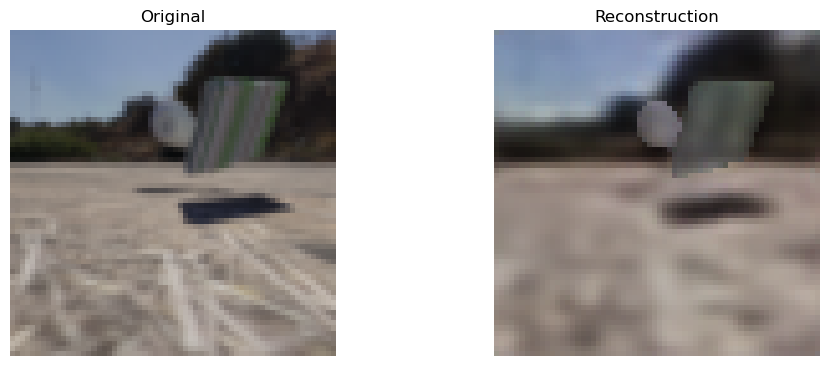

In [17]:
import matplotlib.pyplot as plt
batch = next(iter(val_loader))
sample = batch[0].to(device)
sample_masks = batch[1].to(device)
# autoencoder_obj.to(device)

sample_out = autoencoder_obj((sample, sample_masks))
img_out = sample_out[0]

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(sample[5][0].cpu().detach().permute(1, 2, 0).numpy())
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_out[5][0].cpu().detach().squeeze(0).permute(1, 2, 0).detach().cpu().numpy())
plt.title("Reconstruction")
plt.tight_layout()
plt.axis("off")
plt.show()

In [14]:
from models.masked_object_transformer import MaskedObjectTransformer
from save_load import load_model

autoencoder_obj = MaskedObjectTransformer(obj_num=11, embed_dim=512,
                                          img_size=64, enc_depth=3,
                                          nhead=8, mlp_ratio=4.0)

SAVE_PATH = 'experiments/28-09-2025_14-21_Mask_AE/checkpoints'
optimizer = torch.optim.AdamW(autoencoder_obj.parameters(), lr=1e-4)
load_model(autoencoder_obj, None,
            save_path=SAVE_PATH,
            model_name='epoch_020_iter_73040')

# optimizer is too heavy and not needed, save only model
# def save_models(model, optimizer, scheduler, stats, model_name, save_path):
#     torch.save({
#         'model_state_dict': model.state_dict(),
#         'stats': stats
#     }, f"{save_path}/{model_name}.pth")

# save_models(autoencoder_obj, optimizer, scheduler=None, stats={}, save_path=SAVE_PATH, model_name='epoch_020_iter_73040')

(MaskedObjectTransformer(
   (encoder): SlotTransformerEncoder(
     (encoder_cnn): ObjectCNNEncoder(
       (conv): Sequential(
         (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
         (1): ReLU()
         (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
         (3): ReLU()
         (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
         (5): ReLU()
         (6): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
         (7): ReLU()
       )
       (fc): Linear(in_features=4096, out_features=512, bias=True)
     )
     (encoder): TransformerEncoder(
       (layers): ModuleList(
         (0-2): 3 x TransformerEncoderLayer(
           (self_attn): MultiheadAttention(
             (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
           )
           (linear1): Linear(in_features=512, out_features=2048, bias=True)
           (dropout): Dropout(p=0.1,